William Untung - 2802446573<br>
Streamlit (Local) -> https://creditscoreapplocal-m75dzw3jknis4fxyqdhhmw.streamlit.app/
<br>Streamlit (Cloud) -> http://18.206.237.156:8008/
<br>Link Video: https://drive.google.com/drive/folders/11Yr32skZeUo86PrDUW6mtSeHflO46ROK?usp=sharing
<br>Backup-File: https://drive.google.com/drive/folders/1esa3cKuVC7MBgfPVu-vrl27Lv31RQBXb?usp=sharing

A. Membuat model berbasis machine learning berdasarkan data dan
problem yang ingin diselesaikan<br>
i. fitur yang digunakan,<br>
ii. pre prosesing yang dilakukan,<br>
iii. model machine learning, dan<br>
iv. evaluasi metrik yang digunakan.<br>
v. Anda juga perlu menjelaskan eksperimen apa yang dilakukan untuk mendapat model terbaik.<br>
Anda akan mencoba beberapa model machine learning dalam setiap kali proses training

Berikut adalah deskripsi umum untuk setiap fitur (kolom) dalam dataset Anda. Berdasarkan nama-namanya, dataset ini merupakan data profil keuangan nasabah yang biasa digunakan untuk analisis risiko kredit atau prediksi **Credit Score** (Skor Kredit).

---

### **1. Informasi Demografis & Dasar Nasabah**

* **`Month`**: Bulan pengambilan atau pencatatan data nasabah dalam satu periode waktu.
* **`Age`**: Usia nasabah (dalam satuan tahun).
* **`Occupation`**: Pekerjaan atau profesi utama dari nasabah.

### **2. Pendapatan & Pengeluaran Bulanan**

* **`Annual_Income`**: Total pendapatan kotor nasabah dalam satu tahun.
* **`Monthly_Inhand_Salary`**: Gaji bersih (gaji bawa pulang) yang diterima nasabah setiap bulan setelah dipotong pajak atau asuransi.
* **`Total_EMI_per_month`**: Total cicilan bulanan (*Equated Monthly Installment*) yang harus dibayar nasabah untuk semua pinjaman yang dimilikinya.
* **`Amount_invested_monthly`**: Jumlah uang yang diinvestasikan oleh nasabah setiap bulan (misal ke saham, reksadana, atau instrumen lain).
* **`Monthly_Balance`**: Sisa uang atau saldo yang dimiliki nasabah di akhir bulan setelah dikurangi pengeluaran, investasi, dan cicilan.

### **3. Kepemilikan Akun & Fasilitas Kredit**

* **`Num_Bank_Accounts`**: Jumlah rekening bank aktif yang dimiliki oleh nasabah.
* **`Num_Credit_Card`**: Jumlah kartu kredit aktif yang dipegang oleh nasabah.
* **`Interest_Rate`**: Suku bunga rata-rata yang dikenakan pada pinjaman atau kartu kredit nasabah.
* **`Num_of_Loan`**: Jumlah total pinjaman berjalan yang sedang diambil oleh nasabah.
* **`Type_of_Loan`**: Jenis-jenis pinjaman yang dimiliki nasabah (misal: kredit rumah, kredit kendaraan, pinjaman pribadi, dll.).

### **4. Perilaku Pembayaran & Kredit**

* **`Delay_from_due_date`**: Rata-rata jumlah hari keterlambatan nasabah dalam membayar tagihan dari tanggal jatuh tempo.
* **`Num_of_Delayed_Payment`**: Frekuensi atau berapa kali nasabah terlambat membayar tagihan dalam periode tertentu.
* **`Changed_Credit_Limit`**: Persentase atau nominal perubahan limit (batas maksimal) kartu kredit nasabah sejak pengisian data terakhir.
* **`Num_Credit_Inquiries`**: Jumlah pengecekan riwayat kredit nasabah oleh lembaga keuangan (*credit bureau check*) akibat adanya pengajuan pinjaman baru.
* **`Credit_Mix`**: Kombinasi atau keragaman jenis kredit yang dimiliki nasabah (apakah seimbang antara kredit macet, kredit jangka panjang, kartu kredit, dll.). Biasanya dikategorikan seperti *Good, Standard, Bad*.
* **`Outstanding_Debt`**: Total sisa utang keseluruhan yang belum dilunasi oleh nasabah.
* **`Credit_Utilization_Ratio`**: Rasio penggunaan kredit. Mengukur berapa persen limit kartu kredit yang terpakai dibandingkan dengan total limit yang tersedia.
* **`Credit_History_Age`**: Umur riwayat kredit nasabah (sejak kapan pertama kali memiliki akun kredit/pinjaman, biasanya dalam hitungan bulan atau tahun).
* **`Payment_of_Min_Amount`**: Indikator apakah nasabah sering membayar tagihan kartu kredit hanya dalam jumlah minimum saja (*Yes/No*).
* **`Payment_Behaviour`**: Kebiasaan atau pola pengeluaran dan pembayaran nasabah (misal: pengeluaran tinggi tetapi bayar penuh, atau pengeluaran rendah tapi sering mencicil).

### **5. Target Analisis**

* **`Credit_Score`**: Klasifikasi atau penilaian akhir terhadap kelayakan kredit nasabah (biasanya dikategorikan menjadi *Good, Standard,* atau *Poor*). Kolom ini umumnya digunakan sebagai *target variable* (label) dalam Machine Learning.

## Library

In [84]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Correlation
from scipy.stats import chi2_contingency

# Preprocess
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder

# Model scikit-learn
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Model selain scikit-learn
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [85]:
SEED = 42

## Load Data

In [86]:
df = pd.read_csv("./data_A.csv", sep = ',')

## Data Overview

In [87]:
print(df.shape)
df.head()

(25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,1,5,10,2,"Student Loan, and Debt Consolidation Loan",13,4,12.59,3.0,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",50,18,15.79,10.0,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",14,8,4.03,0.0,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",29,20,8.21,4.0,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",33,NaN,19.7,6.0,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


In [88]:
df.tail()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
24995,24995,0x106bb,CUS_0x3854,June,Kimt,21,774-91-6471,Manager,40100.45,3280.704167,0,4,7,0,NaN,4,12,2.16,4.0,Good,821.74,31.398811,NaN,No,0.000000,119.11335358096089,High_spent_Small_value_payments,468.9570630857058,Good
24996,24996,0x166ec,CUS_0xc80,July,Chris Reesel,31,610-12-1484,Musician,48706.1_,4052.841667,5,3,7,3,"Student Loan, Payday Loan, and Personal Loan",18,10,13.02,7.0,Standard,1083.76,29.566754,17 Years and 4 Months,Yes,107.152558,156.67313580334772,High_spent_Medium_value_payments,391.4584731707637,Standard
24997,24997,0x7e21,CUS_0x16c4,April,Marjag,17,365-26-7399,_______,8473.795,512.149583,4,7,7,3,"Mortgage Loan, Personal Loan, and Not Specified",20,14,12.78,7.0,Standard,1040.14,38.176695,17 Years and 5 Months,Yes,16.798847,41.360646709309634,Low_spent_Small_value_payments,283.05546449166764,Standard
24998,24998,0x199fe,CUS_0x8a50,January,Scottu,23,742-72-0073,Developer,68281.18,5920.098333,4,3,2,2,"Not Specified, and Payday Loan",6,11,9.49,2.0,_,476.18,32.675313,NaN,No,5851.000000,NaN,!@9#%8,591.976496397994,Good
24999,24999,0x21ffd,CUS_0x9176,August,Shupingj,18,217-87-7841,Writer,32144.54,2950.711667,9,7,32,8,"Auto Loan, Student Loan, Debt Consolidation Lo...",28,21,27.29,6.0,Bad,3360.92,37.337103,7 Years and 2 Months,Yes,166.090653,242.1195285751291,Low_spent_Small_value_payments,176.86098522197787,Standard


## Anomaly Detection

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [90]:
print("Duplicated Values:", df.duplicated().sum())

Duplicated Values: 0


In [91]:
ID_cols = ['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN']

for i in ID_cols:
    print(df['Name'].value_counts().sum())

22440
22440
22440
22440
22440


In [92]:
# Columns to drop
drop_cols = ID_cols

df = df.drop(columns=drop_cols)

In [93]:
raw_cat_cols = df.select_dtypes(include = 'object').columns.tolist()
raw_num_cols = df.select_dtypes(include = np.number).columns.tolist()

In [94]:
print(raw_cat_cols)
print(raw_num_cols)

['Month', 'Age', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']
['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']


In [95]:
for i in raw_cat_cols:
    print(df[i].value_counts(), "\n")

Month
April       3173
July        3156
May         3151
March       3139
June        3131
August      3100
February    3087
January     3063
Name: count, dtype: int64 

Age
38      740
26      729
36      706
28      698
27      689
       ... 
6366      1
8246      1
2334      1
5929      1
6197      1
Name: count, Length: 520, dtype: int64 

Occupation
_______          1770
Engineer         1650
Lawyer           1618
Architect        1613
Media_Manager    1575
Accountant       1569
Entrepreneur     1559
Developer        1556
Scientist        1553
Teacher          1552
Mechanic         1529
Journalist       1523
Doctor           1519
Manager          1483
Musician         1474
Writer           1457
Name: count, dtype: int64 

Annual_Income
72524.2      7
105239.46    7
50787.69     7
83408.52     7
29764.37     7
            ..
8087.76_     1
80108.31     1
25838.55_    1
68470.86     1
48706.1_     1
Name: count, Length: 12889, dtype: int64 

Num_of_Loan
2        3536
3        3521


<!-- Data periode 8 bulan (January - August), 

inconsistance features:
- Age (must in integer)
- SSN (must drop)
- Occupation (remove "_______" | "_"*7)
- Annual_Income (must in float)
- Num_of_Loan (must checking value, must in integer)
- Type_of_Loan (To much information, im confuse)
- Num_of_Delayed_Payment (must in integer)
- Changed_Credit_Limit (must in float)
- Credit_Mix (remove "_")
- Outstanding_Debt (must in float)
- Credit_History_Age (change to 1 unit of time, in integer)
- Payment_of_Min_Amount (remove 'NM')
- Amount_invested_monthly (change to float and handle inconsistance "__10000__")
- Payment_Behaviour (remove "!@9#%8" and maybe feature engineering)
- Monthly_Balance (change to float and handle inconsistance "__-333333333333333333333333333__")
- Credit_Score (Imbalance) -->

In [96]:
# Cek apakah ada data yang berubah menjadi string karena ditambahkan karakter tertentu
cat_to_num = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Amount_invested_monthly', 'Monthly_Balance','Changed_Credit_Limit', 'Outstanding_Debt']

for col in cat_to_num:
    mask = df[col].astype(str).str.contains('_', regex=False)
    count = mask.sum()
    sample = df.loc[mask, col].head(5).tolist()
    print(f"\n[{col}]")
    print(f"  Jumlah baris terdampak : {count}")
    print(f"  Contoh nilai           : {sample}")


[Age]
  Jumlah baris terdampak : 1220
  Contoh nilai           : ['39_', '35_', '36_', '44_', '43_']

[Annual_Income]
  Jumlah baris terdampak : 1756
  Contoh nilai           : ['19267.27_', '40554.44_', '62901.08_', '44964.22_', '56797.38_']

[Num_of_Loan]
  Jumlah baris terdampak : 1216
  Contoh nilai           : ['3_', '7_', '2_', '3_', '2_']

[Num_of_Delayed_Payment]
  Jumlah baris terdampak : 663
  Contoh nilai           : ['18_', '1_', '17_', '1_', '19_']

[Amount_invested_monthly]
  Jumlah baris terdampak : 1035
  Contoh nilai           : ['__10000__', '__10000__', '__10000__', '__10000__', '__10000__']

[Monthly_Balance]
  Jumlah baris terdampak : 4
  Contoh nilai           : ['__-333333333333333333333333333__', '__-333333333333333333333333333__', '__-333333333333333333333333333__', '__-333333333333333333333333333__']

[Changed_Credit_Limit]
  Jumlah baris terdampak : 518
  Contoh nilai           : ['_', '_', '_', '_', '_']

[Outstanding_Debt]
  Jumlah baris terdampak : 243
  

In [97]:
for col in cat_to_num:
    before = df[col].astype(str).str.contains('_', regex=False).sum()
    # Hapus semua underscore lalu konversi ke numerik
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('_', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
 
    after = df[col].isna().sum()
    print(f"\n[{col}]")
    print(f"  Baris dengan underscore (sebelum)   : {before}")
    print(f"  NaN setelah konversi                : {after}")
    print(f"  Dtype sekarang                      : {df[col].dtype}")


[Age]
  Baris dengan underscore (sebelum)   : 1220
  NaN setelah konversi                : 0
  Dtype sekarang                      : int64

[Annual_Income]
  Baris dengan underscore (sebelum)   : 1756
  NaN setelah konversi                : 0
  Dtype sekarang                      : float64

[Num_of_Loan]
  Baris dengan underscore (sebelum)   : 1216
  NaN setelah konversi                : 0
  Dtype sekarang                      : int64

[Num_of_Delayed_Payment]
  Baris dengan underscore (sebelum)   : 663
  NaN setelah konversi                : 1733
  Dtype sekarang                      : float64

[Amount_invested_monthly]
  Baris dengan underscore (sebelum)   : 1035
  NaN setelah konversi                : 1164
  Dtype sekarang                      : float64

[Monthly_Balance]
  Baris dengan underscore (sebelum)   : 4
  NaN setelah konversi                : 289
  Dtype sekarang                      : float64

[Changed_Credit_Limit]
  Baris dengan underscore (sebelum)   : 518
  NaN setel

In [98]:
num_cols = df.select_dtypes(include = np.number).columns.tolist()
cat_cols = df.select_dtypes(include = 'object').columns.tolist()

print(len(cat_cols))
print(len(num_cols))

df[num_cols].describe()

8
16


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,25000.000000,2.500000e+04,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,23267.000000,24482.000000,24494.000000,25000.000000,25000.000000,25000.000000,23836.000000,2.471100e+04
mean,105.206600,1.918058e+05,4215.671131,17.235440,22.143080,71.214040,2.847240,21.192000,30.398289,10.380954,28.149669,1430.481253,32.295884,1406.139718,622.600302,-5.395708e+22
std,663.317564,1.531878e+06,3187.623134,118.307474,127.701822,463.669065,61.774169,14.887254,222.617175,6.768413,194.452923,1157.430073,5.090592,8242.321932,2007.704119,4.240697e+24
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,-3.000000,-6.430000,0.000000,0.230000,20.172942,0.000000,0.000000,-3.333333e+26
25%,24.000000,1.955945e+04,1634.720833,4.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.290000,3.000000,565.445000,28.104589,30.750519,74.497400,2.702352e+02
50%,33.000000,3.781363e+04,3111.437500,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.440000,6.000000,1169.760000,32.288376,70.523826,136.362931,3.367995e+02
75%,42.000000,7.309678e+04,5986.647500,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.827500,9.000000,1961.950000,36.480066,163.598381,265.917183,4.691007e+02
max,8698.000000,2.418881e+07,15167.180000,1798.000000,1499.000000,5775.000000,1482.000000,67.000000,4388.000000,36.290000,2597.000000,4998.070000,48.489852,82236.000000,10000.000000,1.555201e+03


## Handle Inconsistance Categorical Columns

In [99]:
for i in cat_cols:
    print(df[i].value_counts(), "\n")

Month
April       3173
July        3156
May         3151
March       3139
June        3131
August      3100
February    3087
January     3063
Name: count, dtype: int64 

Occupation
_______          1770
Engineer         1650
Lawyer           1618
Architect        1613
Media_Manager    1575
Accountant       1569
Entrepreneur     1559
Developer        1556
Scientist        1553
Teacher          1552
Mechanic         1529
Journalist       1523
Doctor           1519
Manager          1483
Musician         1474
Writer           1457
Name: count, dtype: int64 

Type_of_Loan
Not Specified                                                                                                                                           355
Credit-Builder Loan                                                                                                                                     319
Debt Consolidation Loan                                                                                           

In [100]:
df['Credit_History_Age'].head()

0     20 Years and 5 Months
1     14 Years and 8 Months
2    23 Years and 10 Months
3     27 Years and 0 Months
4     10 Years and 3 Months
Name: Credit_History_Age, dtype: object

In [101]:
# 20 Years and 5 Months <- contoh
df['Credit_History_Age'] = df['Credit_History_Age'].apply(
    lambda x: int(x.split(" Years")[0]) * 12 + int(x.split("and")[1].split("Months")[0]) if pd.notna(x) else np.nan
)

df['Credit_History_Age'] = (
    df['Credit_History_Age']
    .astype('Int64')
)

In [102]:
df['Occupation'] = df['Occupation'].replace("_______", np.nan)

df['Credit_Mix'] = df['Credit_Mix'].replace("_", np.nan)

df['Payment_of_Min_Amount'] = (
    df['Payment_of_Min_Amount']
    .replace('NM', np.nan)
)

In [103]:
df['Payment_Behaviour'] = (
    df['Payment_Behaviour']
    .replace("!@9#%8", np.nan)
)

df[['Spending_Level', 'Payments_Value_Level']] = (
    df['Payment_Behaviour']
    .str.replace('_spent_', '_')
    .str.replace('_value_payments', '')
    .str.split('_', expand=True)
)

df = df.drop(columns='Payment_Behaviour')

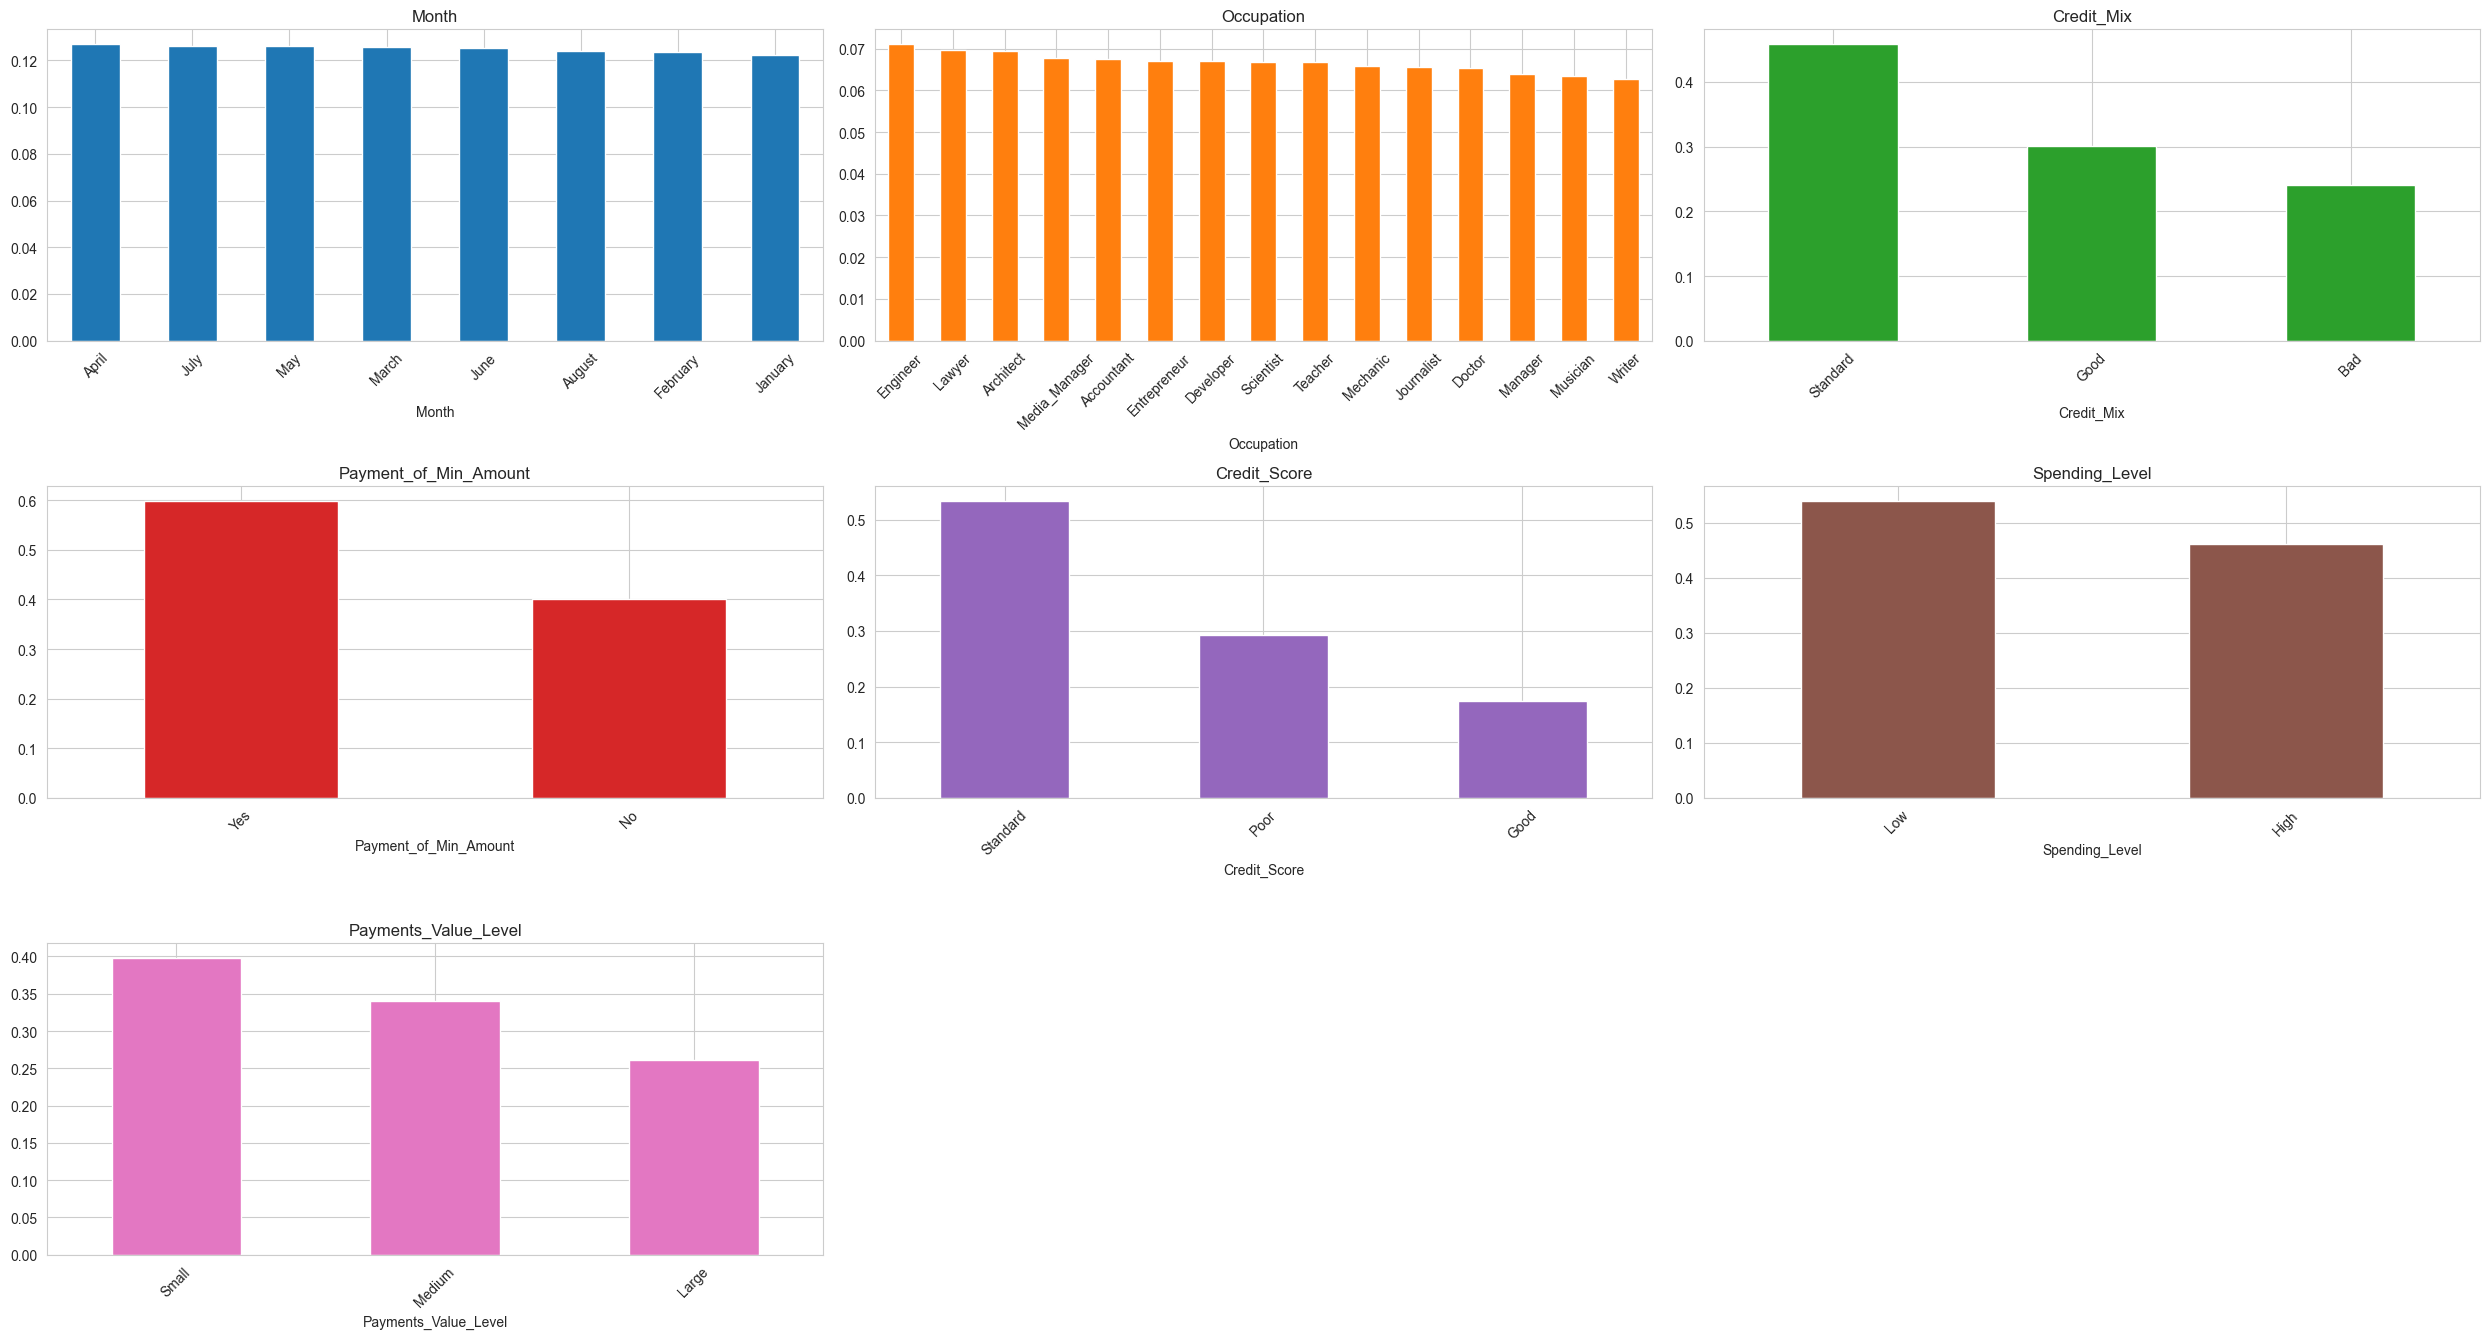

In [104]:
cat_cols = df.select_dtypes(include = 'object').columns.tolist()

sns.set_style('whitegrid')

n_cols = 3
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 4.5))
axes = axes.flatten() 

cat_cols.remove('Type_of_Loan')

for i, col in enumerate(cat_cols):
    df[col].value_counts(normalize=True).plot(kind='bar', ax=axes[i], color = sns.color_palette("tab10")[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Handle Inconsistance Numerical Columns

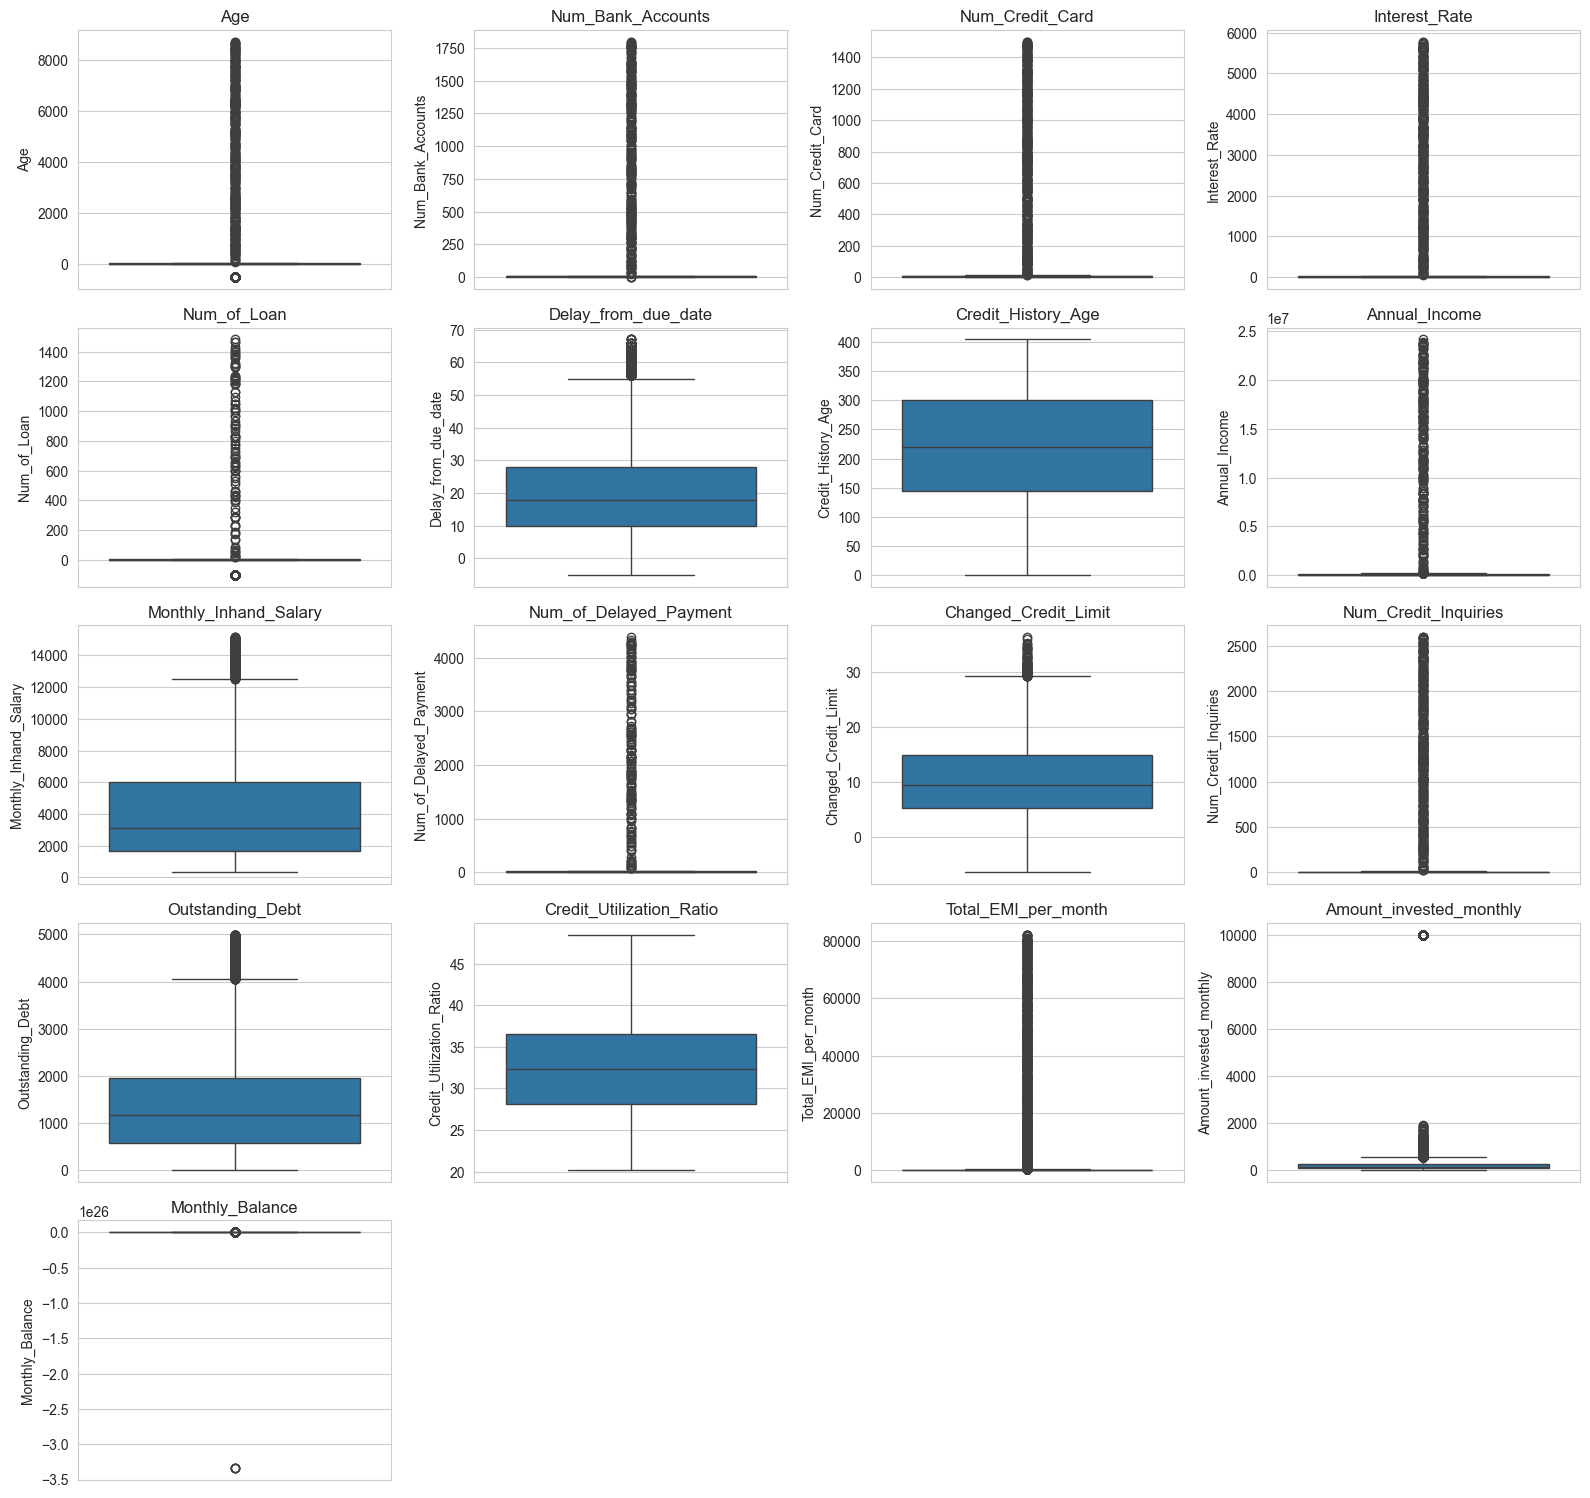

In [105]:
# Box Plot
int_cols = df.select_dtypes(include = 'integer').columns.tolist()
flt_cols = df.select_dtypes(include = 'floating').columns.tolist()

num_cols = int_cols + flt_cols

n_cols = 4
n_rows = math.ceil(len(num_cols)/n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3*n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [106]:
# Age
df.loc[(df['Age'] < 18) | (df['Age'] >= 100), 'Age'] = np.nan

# Non-Negative
df.loc[df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Credit_Card'] < 0, 'Num_Credit_Card'] = np.nan
df.loc[df['Interest_Rate'] < 0, 'Interest_Rate'] = np.nan
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
df.loc[df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = np.nan
df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan
df.loc[df['Num_Credit_Inquiries'] < 0, 'Num_Credit_Inquiries'] = np.nan
df.loc[df['Credit_History_Age'] < 0, 'Credit_History_Age'] = np.nan
df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = np.nan
df.loc[df['Outstanding_Debt'] < 0, 'Outstanding_Debt'] = np.nan
df.loc[df['Total_EMI_per_month'] < 0, 'Total_EMI_per_month'] = np.nan
df.loc[df['Amount_invested_monthly'] < 0, 'Amount_invested_monthly'] = np.nan
df.loc[df['Monthly_Balance'] < 0, 'Monthly_Balance'] = np.nan

# 0 - 100
df.loc[
    (df['Credit_Utilization_Ratio'] < 0) |
    (df['Credit_Utilization_Ratio'] > 100),
    'Credit_Utilization_Ratio'
] = np.nan

In [107]:
(df['Monthly_Inhand_Salary'] > df['Annual_Income']).sum()

0

In [108]:
# EMI (Equated Monthly Installment) / Cicilan Bulanan
(df['Total_EMI_per_month'] * 12 > df['Annual_Income']).sum()

776

In [109]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) | 
        (df[col] > upper)
    ]

    mean_val = df[col].mean()
    median_val = df[col].median()

    outlier_summary[col] = {
        "mean": mean_val,
        "median": median_val,
        "lower_bound": lower,
        "upper_bound": upper,
        "jumlah_outlier": len(outliers),
        "persentase": len(outliers) / len(df) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T

outlier_df['persentase'] = outlier_df['persentase'].round(2)

outlier_df

,mean,median,lower_bound,upper_bound,jumlah_outlier,persentase
Age,34.378521,34.000000,2.000000,66.000000,1.0,0.00
Num_Bank_Accounts,17.238358,6.000000,-0.500000,11.500000,335.0,1.34
Num_Credit_Card,22.143080,5.000000,-0.500000,11.500000,564.0,2.26
Interest_Rate,71.214040,13.000000,-10.000000,38.000000,479.0,1.92
Num_of_Loan,7.038883,3.000000,-2.500000,9.500000,110.0,0.44
Delay_from_due_date,21.349495,18.000000,-17.000000,55.000000,1017.0,4.07
Credit_History_Age,220.614786,219.000000,-89.000000,535.000000,0.0,0.00
Annual_Income,191805.807563,37813.630000,-60746.545000,153402.775000,703.0,2.81
Monthly_Inhand_Salary,4215.671131,3111.437500,-4893.169167,12514.537500,413.0,1.65
Num_of_Delayed_Payment,30.614513,14.000000,-4.500000,31.500000,181.0,0.72


In [110]:
df[num_cols].describe()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Credit_History_Age,Annual_Income,Monthly_Inhand_Salary,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,22860.000000,24996.000000,25000.000000,25000.000000,24021.000000,24833.000000,22751.0,2.500000e+04,21417.000000,23111.000000,24482.000000,24494.000000,25000.000000,25000.000000,25000.000000,23836.000000,24707.000000
mean,34.378521,17.238358,22.143080,71.214040,7.038883,21.349495,220.614786,1.918058e+05,4215.671131,30.614513,10.380954,28.149669,1430.481253,32.295884,1406.139718,622.600302,401.845203
std,10.146229,118.316716,127.701822,463.669065,59.353971,14.812066,99.335388,1.531878e+06,3187.623134,223.351662,6.768413,194.452923,1157.430073,5.090592,8242.321932,2007.704119,212.886045
min,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.0,7.005930e+03,303.645417,0.000000,-6.430000,0.000000,0.230000,20.172942,0.000000,0.000000,0.899335
25%,26.000000,4.000000,4.000000,8.000000,2.000000,10.000000,145.0,1.955945e+04,1634.720833,9.000000,5.290000,3.000000,565.445000,28.104589,30.750519,74.497400,270.253631
50%,34.000000,6.000000,5.000000,13.000000,3.000000,18.000000,219.0,3.781363e+04,3111.437500,14.000000,9.440000,6.000000,1169.760000,32.288376,70.523826,136.362931,336.829461
75%,42.000000,7.000000,7.000000,20.000000,5.000000,28.000000,301.0,7.309678e+04,5986.647500,18.000000,14.827500,9.000000,1961.950000,36.480066,163.598381,265.917183,469.120539
max,95.000000,1798.000000,1499.000000,5775.000000,1482.000000,67.000000,404.0,2.418881e+07,15167.180000,4388.000000,36.290000,2597.000000,4998.070000,48.489852,82236.000000,10000.000000,1555.201051


In [111]:
for i in ['Annual_Income', 'Total_EMI_per_month', 'Amount_invested_monthly']:
    print(df[i].max())

24188807.0
82236.0
10000.0


In [112]:
df[['Annual_Income', 'Total_EMI_per_month', 'Amount_invested_monthly']].describe()

,Annual_Income,Total_EMI_per_month,Amount_invested_monthly
count,2.500000e+04,25000.000000,23836.000000
mean,1.918058e+05,1406.139718,622.600302
std,1.531878e+06,8242.321932,2007.704119
min,7.005930e+03,0.000000,0.000000
25%,1.955945e+04,30.750519,74.497400
50%,3.781363e+04,70.523826,136.362931
75%,7.309678e+04,163.598381,265.917183
max,2.418881e+07,82236.000000,10000.000000


In [113]:
for i in ['Annual_Income', 'Total_EMI_per_month', 'Amount_invested_monthly']:
    idx = df[i].idxmax()
    print(f"--- Max {i} ---")
    print(df.loc[idx, ['Annual_Income', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Inhand_Salary']])
    print()

--- Max Annual_Income ---
Annual_Income               24188807.0
Total_EMI_per_month          87.323423
Amount_invested_monthly      25.385696
Monthly_Inhand_Salary      1067.655833
Name: 292, dtype: object

--- Max Total_EMI_per_month ---
Annual_Income                 44927.86
Total_EMI_per_month            82236.0
Amount_invested_monthly     198.591737
Monthly_Inhand_Salary      3687.988333
Name: 18674, dtype: object

--- Max Amount_invested_monthly ---
Annual_Income                14982.0
Total_EMI_per_month        24.569161
Amount_invested_monthly      10000.0
Monthly_Inhand_Salary         1137.5
Name: 20, dtype: object



In [114]:
1067.655833 * 12

12811.869996000001

In [115]:
outlier_cols = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Annual_Income', 'Total_EMI_per_month', 'Amount_invested_monthly']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Ubah nilai di luar batas lower dan upper menjadi NaN
    df.loc[(df[col] < lower) | (df[col] > upper), col] = np.nan

In [116]:
(df['Total_EMI_per_month'] * 12 > df['Annual_Income']).sum()

0

In [117]:
df.loc[df['Total_EMI_per_month'] * 12 > df['Annual_Income'], 'Total_EMI_per_month'] = np.nan

In [118]:
(df['Amount_invested_monthly'] > df['Annual_Income'] / 12).sum()

0

In [119]:
df.loc[df['Amount_invested_monthly'] > df['Annual_Income'] / 12, 'Amount_invested_monthly'] = np.nan

In [120]:
(df['Total_EMI_per_month'] > df['Outstanding_Debt']).sum()
# Dibiarkan karena tidak diketahui periode data ini diambil setelah pembayaran pinjaman terakhir nasabah atau waktu sedang berjalan
# Justifikasi -> agar model bisa belajar anomaly dari keadaan data

791

In [121]:
# Formating setelah membuat np.nan otomatis dtype kolom jadi float
df['Age'] = (
    df['Age']
    .astype('Int64')
)

df['Num_Bank_Accounts'] = (
    df['Num_Bank_Accounts']
    .astype('Int64')
)

df['Num_Credit_Card'] = (
    df['Num_Credit_Card']
    .astype('Int64')
)

df['Delay_from_due_date'] = (
    df['Delay_from_due_date']
    .astype('Int64')
)

df['Num_of_Loan'] = (
    df['Num_of_Loan']
    .astype('Int64')
)

df['Interest_Rate'] = (
    df['Interest_Rate']
    .astype('Int64')
)

df['Num_of_Delayed_Payment'] = (
    df['Num_of_Delayed_Payment']
    .astype('Int64')
)

df['Num_Credit_Inquiries'] = (
    df['Num_Credit_Inquiries']
    .astype('Int64')
)

In [122]:
int_cols = df.select_dtypes(include = 'integer').columns.tolist()
flt_cols = df.select_dtypes(include = 'floating').columns.tolist()

In [123]:
df[int_cols].describe()

,Age,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_History_Age
count,22860.0,24661.0,24436.0,24521.0,23911.0,24833.0,22930.0,24074.0,22751.0
mean,34.378521,5.376789,5.537281,14.584519,3.561583,21.349495,13.46075,5.793512,220.614786
std,10.146229,2.584743,2.075997,8.750682,2.456677,14.812066,6.194386,3.837347,99.335388
min,18.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
25%,26.0,3.0,4.0,8.0,2.0,10.0,9.0,3.0,145.0
50%,34.0,6.0,5.0,13.0,3.0,18.0,14.0,6.0,219.0
75%,42.0,7.0,7.0,20.0,5.0,28.0,18.0,8.0,301.0
max,95.0,11.0,11.0,34.0,9.0,67.0,28.0,17.0,404.0


In [124]:
df[flt_cols].describe()

,Annual_Income,Monthly_Inhand_Salary,Changed_Credit_Limit,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,24297.000000,21417.000000,24482.000000,25000.000000,25000.000000,23329.000000,21352.000000,24707.000000
mean,48519.327621,4215.671131,10.380954,1430.481253,32.295884,91.198415,156.093632,401.845203
std,35234.537667,3187.623134,6.768413,1157.430073,5.090592,83.886582,117.149788,212.886045
min,7005.930000,303.645417,-6.430000,0.230000,20.172942,0.000000,0.000000,0.899335
25%,19278.720000,1634.720833,5.290000,565.445000,28.104589,28.228425,69.308939,270.253631
50%,36580.660000,3111.437500,9.440000,1169.760000,32.288376,64.306299,121.271290,336.829461
75%,69907.300000,5986.647500,14.827500,1961.950000,36.480066,135.044286,207.551256,469.120539
max,153147.640000,15167.180000,36.290000,4998.070000,48.489852,362.846101,553.022436,1555.201051


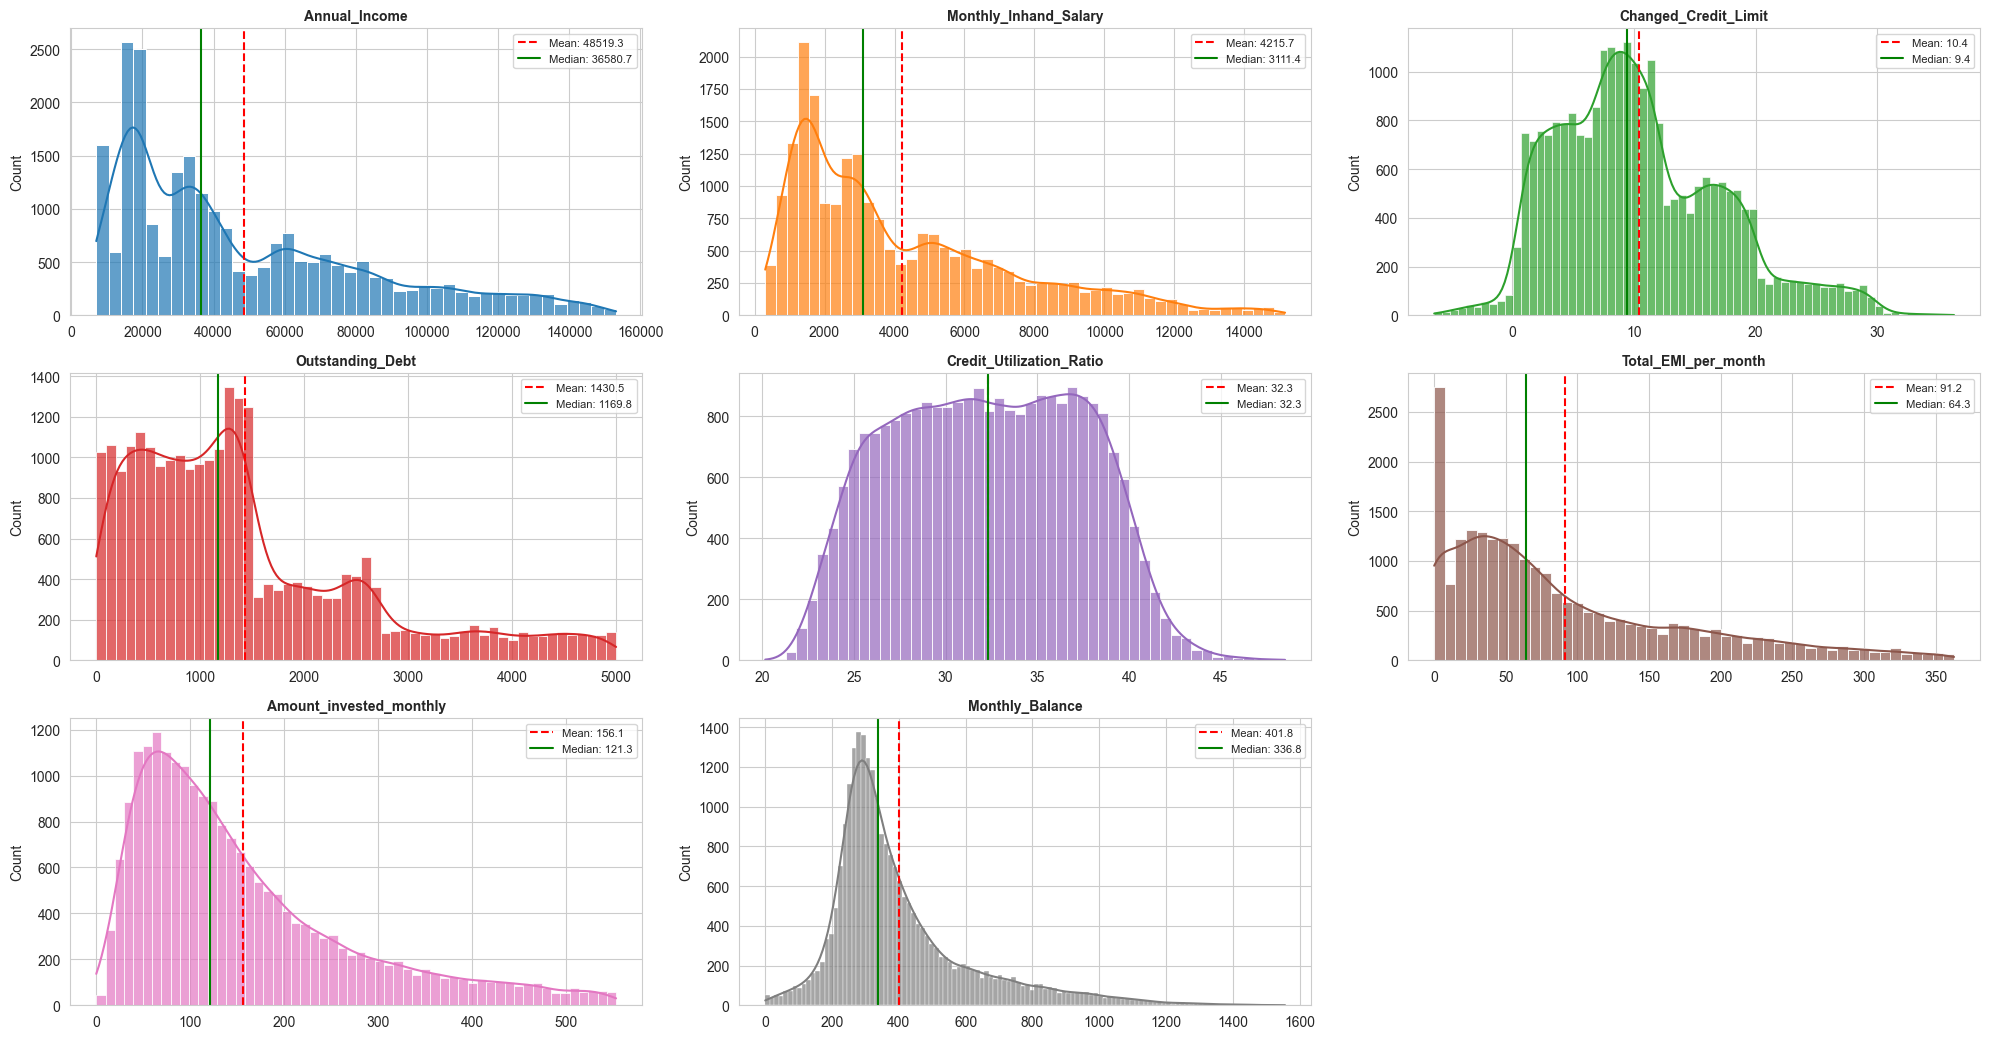

In [125]:
n_cols = 3
n_rows = math.ceil(len(flt_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
axes = axes.flatten()

# flt_cols = set(flt_cols) - set(['Annual_Income', 'Total_EMI_per_month'])

for i, col in enumerate(flt_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("tab10")[i % 10], alpha=0.7)
    
    mean = df[col].mean()
    median = df[col].median()
    
    axes[i].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i].axvline(median, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median:.1f}')
    
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    
    axes[i].legend(loc='upper right', fontsize=8)

# Hapus sisa subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

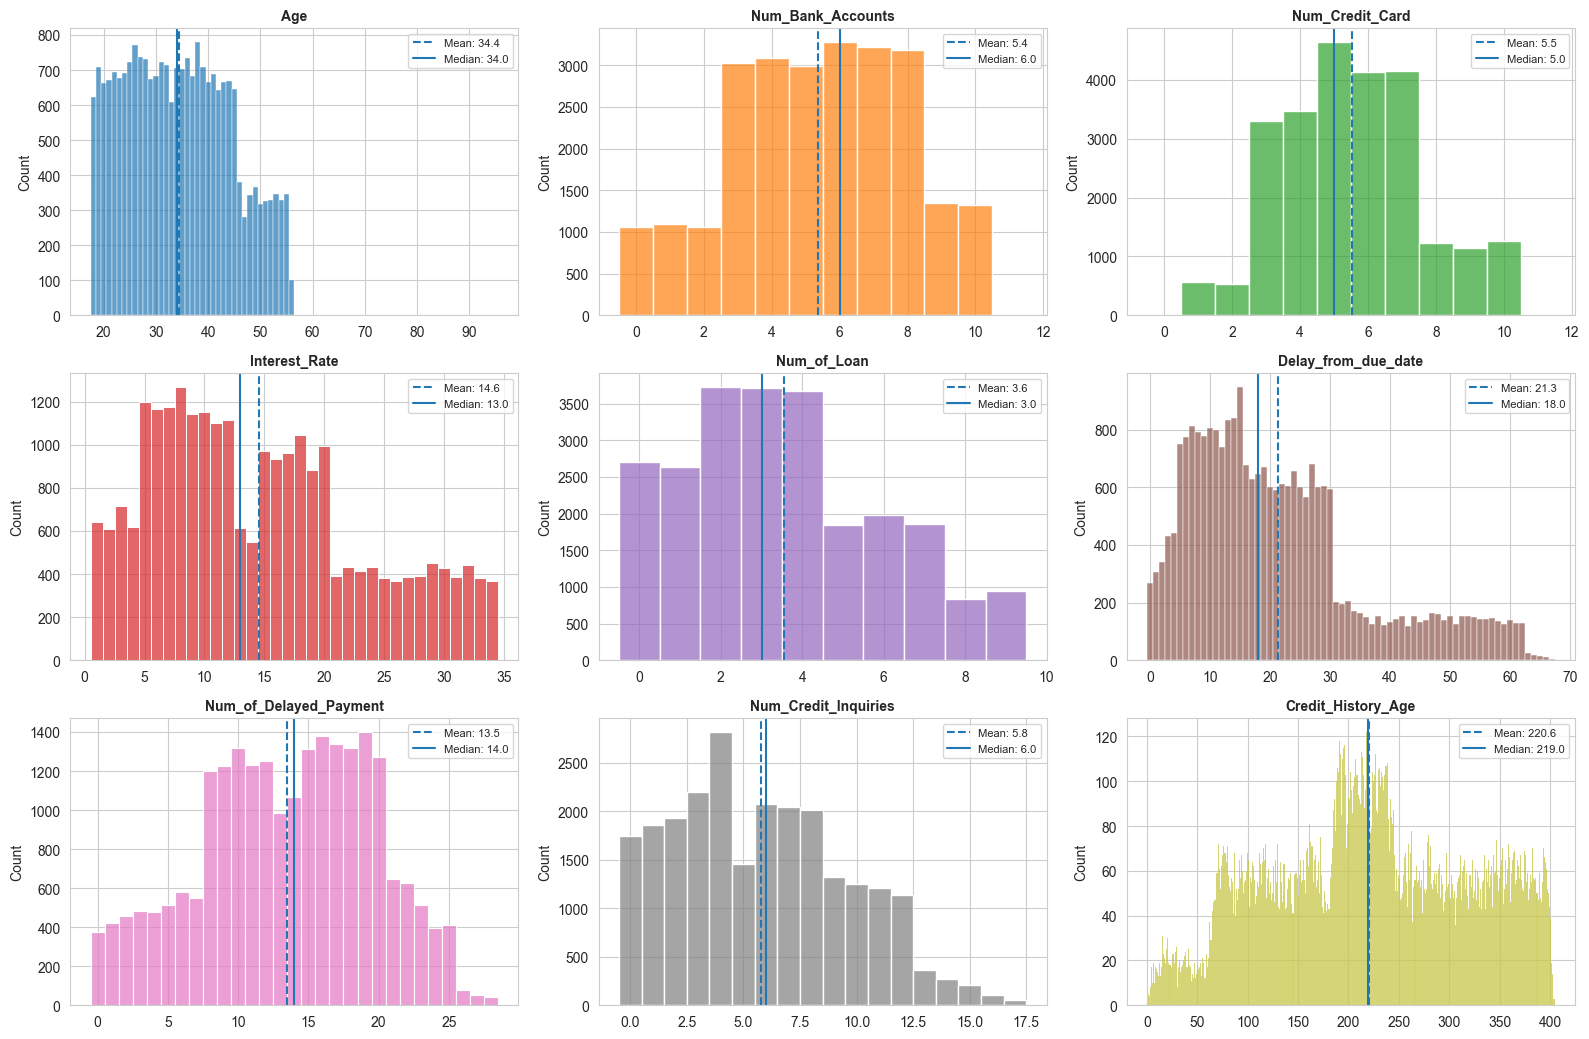

In [126]:
n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3.5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(int_cols):
    sns.histplot(df[col], discrete=True, ax=axes[i], color=sns.color_palette("tab10")[i % 10], alpha=0.7)

    median = df[col].median()
    mean = df[col].mean()

    axes[i].axvline(mean, linestyle="--", linewidth=1.5, label=f"Mean: {mean:.1f}")

    axes[i].axvline(median, linestyle="-", linewidth=1.5, label=f"Median: {median:.1f}")

    axes[i].set_title(col, fontsize=10, fontweight="bold")

    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Feature Engineering

In [127]:
df['Type_of_Loan'] = (
    df['Type_of_Loan']
    .str.replace('and ', '', regex=False)
)

In [128]:
df['Type_of_Loan'].head(10)

0                Student Loan, Debt Consolidation Loan
1    Home Equity Loan, Mortgage Loan, Home Equity L...
2    Credit-Builder Loan, Debt Consolidation Loan, ...
3          Personal Loan, Not Specified, Mortgage Loan
4    Home Equity Loan, Auto Loan, Payday Loan, Not ...
5            Mortgage Loan, Student Loan, Student Loan
6    Debt Consolidation Loan, Credit-Builder Loan, ...
7                                                  NaN
8    Mortgage Loan, Credit-Builder Loan, Debt Conso...
9    Home Equity Loan, Mortgage Loan, Mortgage Loan...
Name: Type_of_Loan, dtype: object

In [129]:
# Best Practice (saya menemukan setelah saya udah launch instance) 
# -> justifikasi = ada informasi yang tidak di terima model yang telah dilaunch yaitu jumlah loan yang dimiliki nasabah dari kolom 'Type_of_Loan'

# loan_counts = (
#     df['Type_of_Loan']
#     .str.split(', ')
#     .explode()
#     .str.strip()
#     .groupby(level=0)
#     .value_counts()
#     .unstack(fill_value=0)
# )

# df = pd.concat([df, loan_counts], axis=1)

In [130]:
loan_dummies = (
    df['Type_of_Loan']
    .str.get_dummies(sep=', ')
)

df = pd.concat([df, loan_dummies], axis=1)

In [131]:
loan_dummies.columns

Index(['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan',
       'Home Equity Loan', 'Mortgage Loan', 'Not Specified', 'Payday Loan',
       'Personal Loan', 'Student Loan'],
      dtype='object')

| Loan Type               | Karakter umum                     |
| ----------------------- | --------------------------------- |
| Mortgage Loan           | hutang besar tapi biasanya stabil |
| Home Equity Loan        | ada aset sebagai jaminan          |
| Auto Loan               | hutang aset kendaraan             |
| Student Loan            | hutang pendidikan                 |
| Credit-Builder Loan     | histori kredit baru               |
| Personal Loan           | tergantung penggunaan             |
| Debt Consolidation Loan | indikasi pernah banyak hutang     |
| Payday Loan             | sering dikaitkan risiko tinggi    |
| Not Specified           | informasi tidak diketahui         |


In [132]:
df[['Type_of_Loan'] + loan_dummies.columns.tolist()].head(10)

,Type_of_Loan,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
0,"Student Loan, Debt Consolidation Loan",0,0,1,0,0,0,0,0,1
1,"Home Equity Loan, Mortgage Loan, Home Equity L...",0,0,1,1,1,1,0,0,0
2,"Credit-Builder Loan, Debt Consolidation Loan, ...",0,1,1,0,0,0,1,0,0
3,"Personal Loan, Not Specified, Mortgage Loan",0,0,0,0,1,1,0,1,0
4,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",1,0,0,1,0,1,1,0,0
5,"Mortgage Loan, Student Loan, Student Loan",0,0,0,0,1,0,0,0,1
6,"Debt Consolidation Loan, Credit-Builder Loan, ...",0,1,1,0,0,0,1,0,0
7,NaN,0,0,0,0,0,0,0,0,0
8,"Mortgage Loan, Credit-Builder Loan, Debt Conso...",0,1,1,0,1,0,0,1,0
9,"Home Equity Loan, Mortgage Loan, Mortgage Loan...",0,0,0,1,1,1,0,0,1


In [133]:
df[['Type_of_Loan']].iloc[9].tolist()

['Home Equity Loan, Mortgage Loan, Mortgage Loan, Not Specified, Student Loan']

In [134]:
df[['Num_of_Loan'] + ['Type_of_Loan'] + loan_dummies.columns.tolist()]

,Num_of_Loan,Type_of_Loan,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
0,2,"Student Loan, Debt Consolidation Loan",0,0,1,0,0,0,0,0,1
1,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",0,0,1,1,1,1,0,0,0
2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",0,1,1,0,0,0,1,0,0
3,3,"Personal Loan, Not Specified, Mortgage Loan",0,0,0,0,1,1,0,1,0
4,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",1,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
24995,0,NaN,0,0,0,0,0,0,0,0,0
24996,3,"Student Loan, Payday Loan, Personal Loan",0,0,0,0,0,0,1,1,1
24997,3,"Mortgage Loan, Personal Loan, Not Specified",0,0,0,0,1,1,0,1,0
24998,2,"Not Specified, Payday Loan",0,0,0,0,0,1,1,0,0


In [135]:
df[['Type_of_Loan']].iloc[2].tolist()

['Credit-Builder Loan, Debt Consolidation Loan, Payday Loan, Debt Consolidation Loan']

In [136]:
df['Type_of_Loan_Count'] = df['Type_of_Loan'].str.count(', ') + 1

In [137]:
df[['Type_of_Loan_Count', 'Num_of_Loan']]

,Type_of_Loan_Count,Num_of_Loan
0,2.0,2
1,5.0,5
2,4.0,4
3,3.0,3
4,6.0,6
...,...,...
24995,NaN,0
24996,3.0,3
24997,3.0,3
24998,2.0,2


In [138]:
df['Num_of_Loan'].isna().sum()

1089

In [139]:
df['Num_of_Loan'] = df['Num_of_Loan'].fillna(df['Type_of_Loan_Count'])

In [140]:
df['Num_of_Loan'].isna().sum()

126

In [141]:
df = df.drop(columns=['Type_of_Loan', 'Type_of_Loan_Count'])

In [142]:
score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Score_encoded'] = df['Credit_Score'].map(score_map)

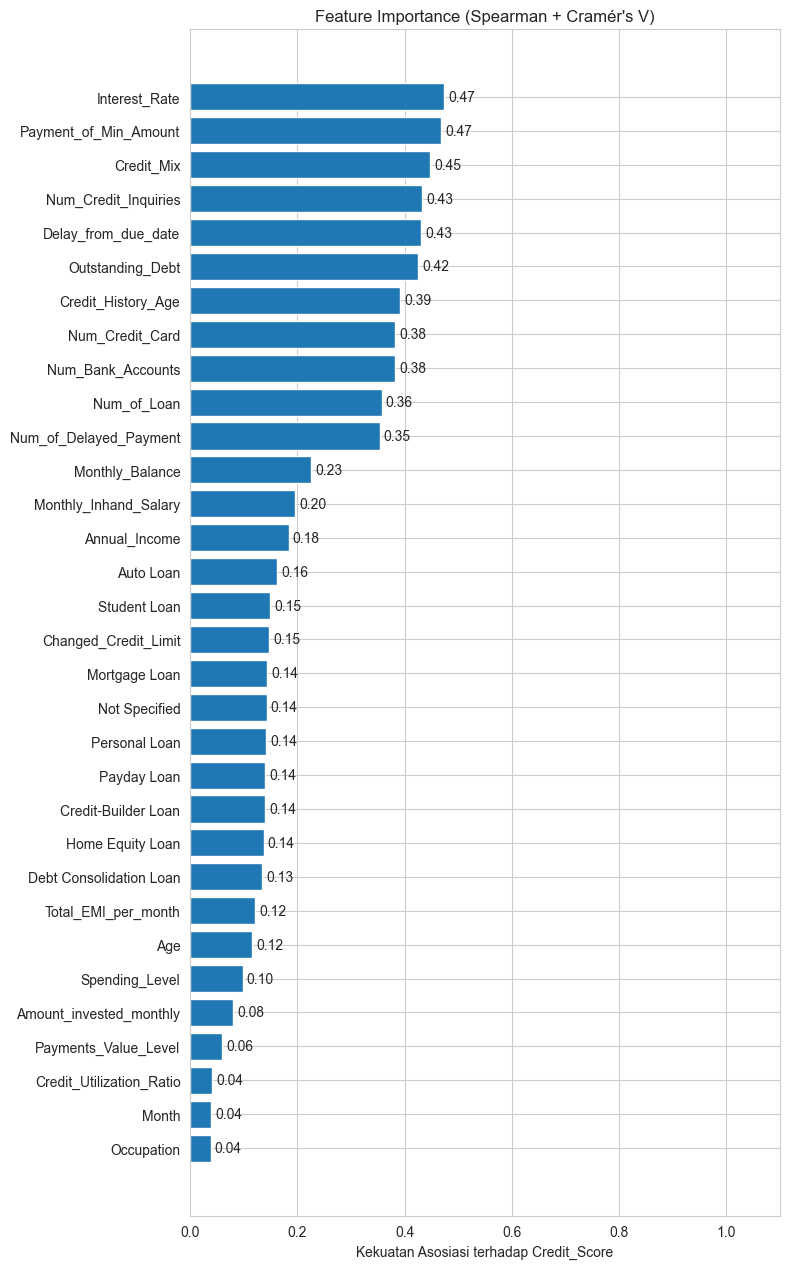

In [143]:
# ── Numerik: Spearman vs Credit_Score
num_corr = (
    df.select_dtypes('number')
    .corrwith(df['Credit_Score_encoded'], method='spearman')
    .abs()
    .drop('Credit_Score_encoded', errors='ignore')
    .rename('correlation')
)

# ── Kategorikal: Cramér's V vs Credit_Score
def cramers_v(col):
    ct = pd.crosstab(df[col], df['Credit_Score'])
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = df.select_dtypes('object').columns.drop('Credit_Score')
cat_corr = pd.Series(
    {col: cramers_v(col) for col in cat_cols},
    name='correlation'
)

# ── Gabung & plot
all_corr = (
    pd.concat([num_corr, cat_corr])
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, len(all_corr) * 0.4))
bars = ax.barh(all_corr.index, all_corr.values)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_xlabel('Kekuatan Asosiasi terhadap Credit_Score')
ax.set_title('Feature Importance (Spearman + Cramér\'s V)')
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.show()

Insight Feature Importance

Berdasarkan hasil pengukuran feature importance menggunakan Spearman Correlation untuk fitur numerik dan Cramér's V untuk fitur kategorikal, Interest_Rate dan Payment_of_Min_Amount merupakan dua fitur yang memiliki hubungan paling kuat dengan Credit_Score, masing-masing dengan nilai asosiasi sebesar 0,47. Selanjutnya, Credit_Mix (0,45), Num_Credit_Inquiries (0,43), Delay_from_due_date (0,43), dan Outstanding_Debt (0,42) juga menunjukkan tingkat asosiasi yang cukup tinggi. Hal ini menunjukkan bahwa Credit_Score lebih dipengaruhi oleh riwayat serta perilaku pengelolaan kredit dibandingkan faktor finansial semata.

Di sisi lain, fitur yang berkaitan dengan pendapatan, seperti Monthly_Inhand_Salary (0,20) dan Annual_Income (0,18), memiliki tingkat asosiasi yang lebih rendah terhadap Credit_Score. Demikian pula dengan Total_EMI_per_month (0,12) dan Amount_invested_monthly (0,08), yang menunjukkan bahwa besarnya pendapatan maupun investasi bulanan tidak memiliki hubungan yang sekuat karakteristik perilaku kredit.

Fitur-fitur hasil encoding dari Type_of_Loan, seperti Auto Loan, Student Loan, Personal Loan, Mortgage Loan, dan jenis pinjaman lainnya, memiliki nilai asosiasi yang relatif seragam, yaitu berkisar antara 0,13–0,16. Hal ini mengindikasikan bahwa setiap jenis pinjaman memberikan kontribusi yang hampir setara terhadap Credit_Score, tanpa ada satu jenis pinjaman yang memiliki pengaruh yang jauh lebih dominan dibandingkan yang lain.

Sementara itu, beberapa fitur seperti Credit_Utilization_Ratio (0,04), Month (0,04), dan Occupation (0,04) memiliki nilai asosiasi yang sangat rendah terhadap Credit_Score, sehingga hubungan langsung antara fitur-fitur tersebut dengan target relatif lemah dibandingkan fitur-fitur lainnya.

In [144]:
# corr = df.select_dtypes('number').corr()

# plt.figure(figsize=(15,10))
# sns.heatmap(
#     corr,
#     cmap='coolwarm',
#     center=0
# )
# plt.show()

In [145]:
df = df.drop(columns='Credit_Score_encoded')

df_list = df.dropna().head(5).values.tolist()

for i in range(len(df_list)):
    print(df_list[i])

['June', 29, 'Musician', 142081.48, 11771.123333333337, 6, 6, 15, 3, 29, 20, 8.21, 4, 'Standard', 932.32, 28.40952606309215, 324, 'No', 180.6164783267737, 423.9612619666837, 862.534593039876, 'Standard', 'Low', 'Small', 0, 0, 0, 0, 1, 1, 0, 1, 0]
['June', 51, 'Journalist', 61358.82, 4923.235, 7, 7, 14, 0, 15, 15, 5.99, 3, 'Standard', 537.91, 35.41872900165368, 302, 'No', 0.0, 161.55547025142175, 600.7680297485782, 'Standard', 'Low', 'Large', 0, 0, 0, 0, 0, 0, 0, 0, 0]
['April', 46, 'Writer', 83823.22, 6841.2683333333325, 3, 5, 11, 1, 6, 9, 10.31, 0, 'Good', 184.71, 37.599297084528814, 245, 'No', 41.30388915808158, 451.5484460829808, 471.27449809227096, 'Poor', 'Low', 'Medium', 1, 0, 0, 0, 0, 0, 0, 0, 0]
['June', 29, 'Doctor', 18002.675, 1430.2229166666666, 6, 3, 10, 3, 27, 15, 0.94, 6, 'Good', 698.05, 29.97544826473301, 339, 'No', 34.03249572465915, 32.72897462630361, 316.2608213157039, 'Good', 'High', 'Large', 0, 0, 1, 0, 0, 0, 0, 1, 0]
['January', 44, 'Teacher', 7161.64, 758.80333333

In [146]:
df.dropna().head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Spending_Level,Payments_Value_Level,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
3,June,29,Musician,142081.480,11771.123333,6,6,15,3,29,20,8.21,4,Standard,932.32,28.409526,324,No,180.616478,423.961262,862.534593,Standard,Low,Small,0,0,0,0,1,1,0,1,0
7,June,51,Journalist,61358.820,4923.235000,7,7,14,0,15,15,5.99,3,Standard,537.91,35.418729,302,No,0.000000,161.555470,600.768030,Standard,Low,Large,0,0,0,0,0,0,0,0,0
12,April,46,Writer,83823.220,6841.268333,3,5,11,1,6,9,10.31,0,Good,184.71,37.599297,245,No,41.303889,451.548446,471.274498,Poor,Low,Medium,1,0,0,0,0,0,0,0,0
13,June,29,Doctor,18002.675,1430.222917,6,3,10,3,27,15,0.94,6,Good,698.05,29.975448,339,No,34.032496,32.728975,316.260821,Good,High,Large,0,0,1,0,0,0,0,1,0
17,January,44,Teacher,7161.640,758.803333,8,8,29,3,24,23,8.61,6,Bad,2669.02,39.282462,133,Yes,12.427226,64.175517,289.277590,Poor,Low,Small,0,1,1,0,0,0,0,0,1


In [147]:
# ['June', 51, 'Journalist', 61358.82, 4923.235, 7, 7, 14, 0, 15, 15, 5.99, 3, 'Standard', 537.91, 35.41872900165368, 302, 'No', 0.0, 161.55547025142175, 600.7680297485782, 'Standard', 'Low', 'Large', 0, 0, 0, 0, 0, 0, 0, 0, 0]
# ['April', 46, 'Writer', 83823.22, 6841.2683333333325, 3, 5, 11, 1, 6, 9, 10.31, 0, 'Good', 184.71, 37.599297084528814, 245, 'No', 41.30388915808158, 451.5484460829808, 471.27449809227096, 'Poor', 'Low', 'Medium', 1, 0, 0, 0, 0, 0, 0, 0, 0]
# ['June', 29, 'Doctor', 18002.675, 1430.2229166666666, 6, 3, 10, 3, 27, 15, 0.94, 6, 'Good', 698.05, 29.97544826473301, 339, 'No', 34.03249572465915, 32.72897462630361, 316.2608213157039, 'Good', 'High', 'Large', 0, 0, 1, 0, 0, 0, 0, 1, 0]

## Modeling Experiments

### Spliting Data

In [148]:
x = df.drop('Credit_Score', axis = 1)
y = df['Credit_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=SEED)

In [149]:
y.isna().sum()

0

In [150]:
print("Split Distribution")
print(x_train.shape)
print(y_train.value_counts())
print(x_test.shape)
print(y_test.value_counts())

Split Distribution
(20000, 32)
Credit_Score
Standard    10664
Poor         5842
Good         3494
Name: count, dtype: int64
(5000, 32)
Credit_Score
Standard    2666
Poor        1460
Good         874
Name: count, dtype: int64


In [151]:
# x_train.columns

### Column Transformer (Preprocessing)

In [152]:
cat_cols = x_train.select_dtypes(include='object').columns.tolist()
num_cols = x_train.select_dtypes(include=np.number).columns.tolist()

In [153]:
# for i in cat_cols:
#     print(df[i].value_counts(), '\n')

In [154]:
ohe_cols = ['Month', 'Occupation']
ord_cols = ['Payments_Value_Level', 'Spending_Level', 'Payment_of_Min_Amount', 'Credit_Mix'] 

In [155]:
print(ord_cols, f'\n{ohe_cols}')

['Payments_Value_Level', 'Spending_Level', 'Payment_of_Min_Amount', 'Credit_Mix'] 
['Month', 'Occupation']


In [156]:
df[num_cols]

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
0,<NA>,100433.580,8074.465000,1,5,10,2,13,4,12.59,3,1023.93,33.471395,245,100.163466,NaN,229.212547,0,0,1,0,0,0,0,0,1
1,25,33119.820,3024.985000,10,5,32,5,50,18,15.79,10,2545.00,33.810567,176,111.422702,NaN,370.607498,0,0,1,1,1,1,0,0,0
2,44,44822.210,3555.184167,1,4,2,4,14,8,4.03,0,730.64,31.145739,286,135.044286,256.474297,243.999834,0,1,1,0,0,0,1,0,0
3,29,142081.480,11771.123333,6,6,15,3,29,20,8.21,4,932.32,28.409526,324,180.616478,423.961262,862.534593,0,0,0,0,1,1,0,1,0
4,45,19267.270,1374.605833,10,8,25,6,33,<NA>,19.70,6,3777.55,28.373426,123,78.954825,133.568502,214.937256,1,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,21,40100.450,3280.704167,0,4,7,0,4,12,2.16,4,821.74,31.398811,<NA>,0.000000,119.113354,468.957063,0,0,0,0,0,0,0,0,0
24996,31,48706.100,4052.841667,5,3,7,3,18,10,13.02,7,1083.76,29.566754,208,107.152558,156.673136,391.458473,0,0,0,0,0,0,1,1,1
24997,<NA>,8473.795,512.149583,4,7,7,3,20,14,12.78,7,1040.14,38.176695,209,16.798847,41.360647,283.055464,0,0,0,0,1,1,0,1,0
24998,23,68281.180,5920.098333,4,3,2,2,6,11,9.49,2,476.18,32.675313,<NA>,NaN,NaN,591.976496,0,0,0,0,0,1,1,0,0


In [157]:
int_cols = ['Age', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Credit_History_Age']
bin_cols = ['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan']
flt_cols = list(set(num_cols) - set(int_cols) - set(bin_cols))

In [158]:
print(int_cols, f'\n{flt_cols}', f'\n{bin_cols}')

['Age', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Credit_History_Age'] 
['Outstanding_Debt', 'Credit_Utilization_Ratio', 'Monthly_Inhand_Salary', 'Changed_Credit_Limit', 'Monthly_Balance', 'Amount_invested_monthly', 'Total_EMI_per_month', 'Annual_Income'] 
['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan']


In [159]:
for i in ord_cols:
    print(i, df[i].unique())

Payments_Value_Level ['Medium' 'Small' 'Large' nan]
Spending_Level ['Low' 'High' nan]
Payment_of_Min_Amount ['No' 'Yes' nan]
Credit_Mix ['Good' 'Bad' 'Standard' nan]


In [160]:
int_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

flt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

ord_categories = [
    ['Small', 'Medium', 'Large'], 
    ['Low', 'High'], 
    ['No', 'Yes'],
    ['Bad', 'Standard', 'Good'], 
]

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ord_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('int', int_pipeline, int_cols),
    ('float', flt_pipeline, flt_cols),
    ('bin', 'passthrough', bin_cols),
    ('ohe', ohe_pipeline, ohe_cols),
    ('ord', ord_pipeline, ord_cols)
], remainder='drop')

### Training Model

In [161]:
# lr = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', LogisticRegression(
#         random_state=SEED
#     ))
# ])

# et = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', ExtraTreesClassifier(
#         random_state=SEED
#     ))
# ])

# rf = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', RandomForestClassifier(
#         random_state=SEED
#     ))
# ])

# xgb = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', XGBClassifier(
#         random_state=SEED,
#         eval_metric='logloss',
#         use_label_encoder=True
#     ))
# ])

# lgbm = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', LGBMClassifier(
#         random_state=SEED,
#         verbosity=-1
#     ))
# ])

# catboost = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', CatBoostClassifier(
#         random_seed=SEED,
#         verbose=0
#     ))
# ])

# hist_gb = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', HistGradientBoostingClassifier(
#         random_state=SEED
#     ))
# ])

In [162]:
# lr.fit(x_train, y_train)
# et.fit(x_train, y_train)
# rf.fit(x_train, y_train)
# xgb.fit(x_train, y_train)
# lgbm.fit(x_train, y_train)
# catboost.fit(x_train, y_train)
# hist_gb.fit(x_train, y_train)

## Hyperparameter Tuning

### Tuning Setup

In [163]:
lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=SEED
    ))
])

et = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', ExtraTreesClassifier(
        random_state=SEED
    ))
])

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=SEED
    ))
])

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=SEED,
        eval_metric='logloss',
        use_label_encoder=True
    ))
])

lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        random_state=SEED,
        verbosity=-1
    ))
])

catboost = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        random_seed=SEED,
        verbose=0
    ))
])

hist_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        random_state=SEED
    ))
])

In [164]:
# default: 1.0 | 'l2' | 'saga' | 1000
param_logistic = {
    'classifier__C': [0.01, 0.1, 1.0],                      # Mengontrol kekuatan regularisasi (makin kecil, makin kuat)
    'classifier__penalty': ['l2', 'l1', 'elasticnet'],      # Jenis regularisasi (yang didukung saga)
    'classifier__solver': ['saga'],                         # Hanya saga yang support 2 penalty
    'classifier__max_iter': [100, 500, 1000]                # Algoritma optimasi untuk konvergensi model
}

# default:None | 2 | 'sqrt'
param_et = {
    'classifier__max_depth': [5, 10, None],                 # Batasan kedalaman pohon
    'classifier__min_samples_split': [2, 5, 10],            # Sampel minimum untuk split node
    'classifier__max_features': ['sqrt', 'log2', None]      # Jumlah fitur yang dipertimbangkan acak saat split
}

# default: 100 | None | 2
param_rf = {
    'classifier__n_estimators': [100, 300],                 # Jumlah pohon keputusan di dalam forest
    'classifier__max_depth': [5, 10, None],                 # Batasan kedalaman pohon untuk mencegah overfitting
    'classifier__min_samples_split': [2, 5, 10]             # Jumlah minimum sampel untuk memecah sebuah node
}

# default: 100 | 0.3 | 6
param_xgb = {
    'classifier__n_estimators': [100, 200, 300, 500],       # Jumlah tahapan boosting (iterasi pohon)
    'classifier__learning_rate': [0.001, 0.01, 0.05, 0.3],  # Menentukan seberapa agresif setiap pohon memperbaiki error sebelumnya
    'classifier__max_depth': [3, 5, 6],                     # Kedalaman maksimum setiap pohon
    'classifier__subsample': [0.8, 1.0]                     # Mengambil 80% atau 100% data baris acak per pohon (anti-overfitting)
}

# default: 100 | 0.1 | 31
param_lgbm = {
    'classifier__n_estimators': [100, 200],                 # Jumlah pohon / iterasi boosting
    'classifier__learning_rate': [0.01, 0.05, 0.1],         # Tingkat pembelajaran (shrinkage pengetatan bobot)
    'classifier__num_leaves': [15, 31, 63]                  # Jumlah maksimum daun dalam satu pohon (kunci tuning LightGBM)
}

# default: 1000 | by dataset size | 6
param_catboost = {
    'classifier__iterations': [100, 1000],                  # seperti n_estimators (jumlah iterasi training)
    'classifier__learning_rate': [0.01, 0.05, 0.1],         # Kecepatan adaptasi model terhadap error
    'classifier__depth': [4, 6, 8]                          # Kedalaman pohon (CatBoost menyarankan rentang 4 hingga 10)
}

# default: 100 | 0.1 | 31
param_hist_gb = {
    'classifier__max_iter': [100, 200, 1000],               # n_estimators (jumlah maksimum iterasi boosting)
    'classifier__learning_rate': [0.01, 0.05, 0.1],         # Pengali untuk kontribusi setiap pohon baru
    'classifier__max_leaf_nodes': [15, 31, 63]              # Jumlah maksimum ujung daun (mirip num_leaves pada LightGBM)
}

In [165]:
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=param_logistic,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

et_grid = GridSearchCV(
    estimator=et,
    param_grid=param_et,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_rf,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_xgb,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

lgbm_grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_lgbm,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

catboost_grid = GridSearchCV(
    estimator=catboost,
    param_grid=param_catboost,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

hist_gb_grid = GridSearchCV(
    estimator=hist_gb,
    param_grid=param_hist_gb,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

In [166]:
models = {
    "Logistic Regression (SAGA Optimizer)": lr_grid,
    "Extremely Randomized Trees (Extra Trees)": et_grid,
    "Random Forest Ensemble": rf_grid,
    "XGBoost (Extreme Gradient Boosting)": xgb_grid,
    "LightGBM (Light Gradient Boosting)": lgbm_grid,
    "CatBoost (Categorical Boosting)": catboost_grid,
    "Histogram-based Gradient Boosting": hist_gb_grid
}

In [167]:
target_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}

y_train = y_train.map(target_mapping)
y_test = y_test.map(target_mapping)
y_train

6336     1
7772     1
8051     1
12015    1
12752    2
        ..
10193    2
21044    1
16236    1
7178     1
22000    0
Name: Credit_Score, Length: 20000, dtype: int64

### Grid Search Cross Validation

In [168]:
results = {}

for name, model in models.items():
    print(f"\n" + "="*60)
    print(f"Training & Evaluating {name}")
    print("="*60)
    
    start_time = datetime.now().replace(microsecond=0)
    
    print(f"Training {name} Mulai: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")

    model.fit(x_train, y_train)
    
    end_time = datetime.now().replace(microsecond=0)
    duration = end_time - start_time

    print(f"Training {name} Selesai: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total Waktu Training {name}: {duration}")
    
    best_params = model.best_params_
    print(f"\nBest Hyperparameters untuk {name}:")
    for param, value in best_params.items():
        print(f"  - {param}: {value}")

    best_model = model.best_estimator_
    y_pred = best_model.predict(x_test)
    
    print(f"\nClassification Report untuk {name}:")
    print(classification_report(y_test, y_pred, target_names=['Poor', 'Standard', 'Good']))
    
    results[name] = {
        "best_params": best_params,  
        "best_cv_score": model.best_score_,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "f1": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "training_duration": str(duration)
    }


Training & Evaluating Logistic Regression (SAGA Optimizer)
Training Logistic Regression (SAGA Optimizer) Mulai: 2026-07-02 21:33:09
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Training Logistic Regression (SAGA Optimizer) Selesai: 2026-07-02 21:33:18
Total Waktu Training Logistic Regression (SAGA Optimizer): 0:00:09

Best Hyperparameters untuk Logistic Regression (SAGA Optimizer):
  - classifier__C: 0.1
  - classifier__max_iter: 100
  - classifier__penalty: l2
  - classifier__solver: saga

Classification Report untuk Logistic Regression (SAGA Optimizer):
              precision    recall  f1-score   support

        Poor       0.69      0.52      0.59      1460
    Standard       0.66      0.78      0.71      2666
        Good       0.56      0.49      0.52       874

    accuracy                           0.65      5000
   macro avg       0.64      0.59      0.61      5000
weighted avg       0.65      0.65      0.64      5000


Training & Evaluating Extremely Randomi

### Grid Search Result

In [169]:
df_results = pd.DataFrame(results).T
# df_results = df_results.sort_values(by="f1", ascending=False)

df_results.drop(columns=['best_params'])

,best_cv_score,accuracy,precision,recall,f1,training_duration
Logistic Regression (SAGA Optimizer),0.594501,0.6512,0.650852,0.6512,0.644694,0:00:09
Extremely Randomized Trees (Extra Trees),0.687243,0.7448,0.744296,0.7448,0.744333,0:00:34
Random Forest Ensemble,0.692856,0.7408,0.740406,0.7408,0.740128,0:00:38
XGBoost (Extreme Gradient Boosting),0.683195,0.736,0.735007,0.736,0.734877,0:01:44
LightGBM (Light Gradient Boosting),0.683749,0.732,0.730689,0.732,0.730892,0:00:36
CatBoost (Categorical Boosting),0.679619,0.7306,0.730266,0.7306,0.729856,0:02:35
Histogram-based Gradient Boosting,0.676214,0.7242,0.724584,0.7242,0.723983,0:00:38


In [170]:
for i in range(len(df_results)):
    model_name = df_results.index[i]
    best_params = df_results['best_params'].iloc[i]
    
    print(f"\n[{i+1}] {model_name}:")
    for param, value in best_params.items():
        print(f"    - {param}: {value}")


[1] Logistic Regression (SAGA Optimizer):
    - classifier__C: 0.1
    - classifier__max_iter: 100
    - classifier__penalty: l2
    - classifier__solver: saga

[2] Extremely Randomized Trees (Extra Trees):
    - classifier__max_depth: None
    - classifier__max_features: None
    - classifier__min_samples_split: 10

[3] Random Forest Ensemble:
    - classifier__max_depth: None
    - classifier__min_samples_split: 5
    - classifier__n_estimators: 300

[4] XGBoost (Extreme Gradient Boosting):
    - classifier__learning_rate: 0.05
    - classifier__max_depth: 6
    - classifier__n_estimators: 500
    - classifier__subsample: 0.8

[5] LightGBM (Light Gradient Boosting):
    - classifier__learning_rate: 0.1
    - classifier__n_estimators: 200
    - classifier__num_leaves: 63

[6] CatBoost (Categorical Boosting):
    - classifier__depth: 8
    - classifier__iterations: 1000
    - classifier__learning_rate: 0.05

[7] Histogram-based Gradient Boosting:
    - classifier__learning_rate: 0.05


# Insight & Evaluasi Model: Extra Trees Classifier (Model yang dipilih)

## Ringkasan Performa

Model Extra Trees mencapai **accuracy 0.74** dan **weighted f1 0.74**, namun terdapat gap dengan **macro f1 (0.72)** yang mengindikasikan performa antar kelas belum merata. Gap ini berasal dari **class imbalance** pada data training:

| Kelas | Support | Proporsi |
|---|---|---|
| Standard | 2666 | 53,3% |
| Poor | 1460 | 29,2% |
| Good | 874 | 17,5% |

## Distribusi Kelas Mencerminkan Kondisi Real-World

Distribusi ini (Standard > Poor > Good) selaras dengan pola credit score di dunia nyata, di mana mayoritas populasi umumnya berada di kategori menengah, sementara kelas ekstrem (khususnya "Good") secara natural lebih jarang ditemukan. Hal ini menunjukkan model belajar dari distribusi data yang representatif terhadap kondisi populasi target, bukan sekadar artefak sampling.

## F1 Macro sebagai Scoring GridSearch

GridSearch pada eksperimen ini menggunakan **f1_macro** sebagai scoring, dengan tujuan mendorong keseimbangan performa di seluruh kelas — termasuk kelas minoritas (Good). Hasil akhir menunjukkan:

- Kelas **Standard** dan **Poor** mencapai performa solid (f1 masing-masing 0.78 dan 0.75).
- Kelas **Good** masih tertinggal (precision 0.64, recall 0.62, f1 0.63), konsisten dengan proporsi datanya yang paling kecil.
- Macro f1 di test set (0.72) berada sedikit di bawah weighted f1 (0.74), mengonfirmasi bahwa gap performa terkonsentrasi pada kelas minoritas.

Penggunaan f1_macro dalam scoring menunjukkan bahwa proses seleksi model sudah diarahkan untuk mempertimbangkan keseimbangan antar kelas, bukan hanya mengejar accuracy tertinggi — dan hasil model terbaik yang terpilih tetap mampu mempertahankan performa yang wajar di kelas mayoritas maupun minoritas mengikuti proporsi data aslinya.

## Konsistensi Antar Model

Seluruh model tree-based yang diuji (Extra Trees, Random Forest, XGBoost, LightGBM, CatBoost, HistGB) berada pada rentang accuracy yang berdekatan (0.72–0.74), menunjukkan performa sudah relatif konsisten dan stabil lintas algoritma pada dataset ini.

## Kesimpulan

Model menunjukkan kemampuan generalisasi yang baik dan pola pembelajaran yang sesuai dengan karakteristik data real-world, sehingga **layak dilanjutkan ke tahap eksperimen berikutnya**. Area yang masih terbuka untuk dieksplorasi lebih lanjut adalah peningkatan performa pada kelas minoritas (Good), mengingat kelas ini secara natural memiliki representasi data yang lebih terbatas dibanding Standard dan Poor.

**Thankyou**